
# Rapport de Recherche : Analyse du Réseau de Collaboration Scientifique Arxiv Gr-Qc

**Date :** 19 Avril 2024  
**Cours :** Analyse des Réseaux Sociaux (ARS)  
**Niveau :** Master 1 Recherche  
**Étudiant :** Narjess Ounais 

**Dépôt GitHub :** 

---

## Résumé Exécutif
Ce rapport présente une analyse structurelle approfondie du réseau de collaboration scientifique **ca-GrQc**. À travers l'étude de 4 158 chercheurs et 13 422 interactions, nous avons mis en évidence une topologie de type "Petit Monde" (Small World) caractérisée par une forte cohésion locale. L'application de l'algorithme de Louvain a révélé une structure communautaire extrêmement marquée (modularité de 0,84), témoignant d'une organisation de la recherche en silos thématiques spécialisés.

---

## 1. Introduction
L'analyse des réseaux de collaboration (co-autorat) permet de cartographier l'architecture d'un domaine scientifique. Dans ce projet, nous étudions le réseau **General Relativity and Quantum Cosmology (Gr-Qc)** issu de l'archive Arxiv. 

**Problématique :** Comment la structure topologique du réseau ca-GrQc influence-t-elle la diffusion du savoir et comment les chercheurs se regroupent-ils en communautés distinctes ?

---

## 2. Partie 1 : Collecte et Modélisation des Données

### 2.1 Identification et Justification de la Source
Le choix s'est porté sur le jeu de données ca-GrQc (Collaboration Network of Arxiv General Relativity). Cette base de données est issue de l'archive de prépublications scientifiques Arxiv et est mise à disposition par le dépôt SNAP (Stanford Network Analysis Project) ainsi que sur le Network Repository.
##### Justification du choix :
- **Pertinence thématique  :** Ce réseau illustre parfaitement une structure sociale complexe où les interactions ne sont pas aléatoires mais dictées par l'expertise scientifique.
- **Volume de données :** Avec 4 158 nœuds, le dataset s'inscrit précisément dans la fourchette recommandée (1k - 5k nœuds), permettant des calculs complexes tout en restant interprétables.
- **Fiabilité :** Arxiv est une source académique de référence, garantissant que les liens modélisés correspondent à des collaborations réelles et vérifiables.

### 2.2 Définition Sémantique du Réseau
La transformation des données textuelles en graphe nécessite une définition rigoureuse des entités et de leurs interactions.
#### 2.2.1 Les Entités (Nœuds):
Chaque nœud u ∈ V du graphe représente un chercheur unique (auteur) ayant publié au moins un article dans la catégorie "General Relativity and Quantum Cosmology" sur une période de 10 ans. Dans le dataset, ces chercheurs sont anonymisés et représentés par des identifiants numériques uniques.
#### 2.2.2 Les Relations (Liens):

Une arête e = {u,v} ∈ E est établie entre deux nœuds si et seulement si les deux chercheurs ont co-signé au moins un article scientifique ensemble.

* **Nature du lien :** Il s'agit d'une relation de collaboration académique.
* **Type de graphe :** Le réseau est non-orienté (Undirected). La co-publication est une relation symétrique : si l'auteur A collabore avec l'auteur B, l'inverse est nécessairement vrai.
  
### 2.3 Informations Additionnelles et Attributs
Le dataset utilisé est un graphe simple. Voici les précisions sur les informations complémentaires :
* **Poids des liens (Weights) :** Bien que dans la réalité deux auteurs puissent collaborer plusieurs fois, ce dataset spécifique traite la relation de manière binaire (0 ou 1). Le graphe est donc non-pondéré.
* **Attributs des nœuds :** Les métadonnées telles que l'affiliation institutionnelle ou le pays ne sont pas présentes dans ce fichier pour garantir l'anonymat, focalisant ainsi l'étude sur la topologie pure du réseau.

### 2.4 Protocole d'Obtention et Construction

Le processus technique de récupération et de construction s'est déroulé en trois étapes :
* **Extraction :** Téléchargement du fichier source au format adjacence list ou edge list (extension .txt ou .mtx).
* **Parsing :** Utilisation de la bibliothèque NetworkX pour lire la liste d'arêtes. Le script ignore les lignes de commentaires (débutant par #) et convertit les paires d'identifiants en structures de données exploitables.
* **Nettoyage (Prétraitement) :**
  * Élimination des éventuelles boucles simples (un auteur ne peut pas collaborer avec lui-même dans ce cadre).
  * Vérification de la cohérence : s'assurer que le nombre de liens (13 422) correspond aux standards du dépôt SNAP pour ce dataset.

### 2.5 Synthèse des caractéristiques de l'échantillon

| Caractéristique |	Valeur |
| :--- | :---: |
Nom du Dataset	| ca-GrQc
Nombre de Nœuds (Auteurs) |	4 158
Nombre de Liens (Co-signatures)	 | 13 422
Type de Graphe	 | Non-orienté, Simple
Format Source	| Edge List (.txt)

---

## 3. Partie 2 : Analyse Topologique et Structurelle du Réseau

L’analyse du réseau a été effectuée à l'aide de la bibliothèque NetworkX. Cette étape vise à caractériser la morphologie du graphe à travers des métriques globales et locales, permettant de comprendre comment la communauté Gr-Qc est structurée.

### 3.1  Analyse de la Distribution des Degrés (k)
Le degré d'un nœud correspond au nombre de collaborateurs directs d'un chercheur. L'observation de la distribution des degrés est le premier indicateur de la nature du réseau.

- **Résultats :** L'histogramme généré présente une décroissance rapide, typique d'une Loi de Puissance (P(k)∼k −γ). La majorité des chercheurs possèdent entre 1 et 3 liens, tandis qu'une infime minorité possède plus de 80 collaborations.
- **Interprétation Scientifique :** Le réseau est de type **"Scale-free"** (invariant d'échelle). Dans le monde académique, cela illustre le mécanisme d'**attachement préférentiel** (effet Matthieu) : les chercheurs déjà célèbres et très connectés attirent mathématiquement plus de nouveaux collaborateurs, renforçant ainsi leur position de **"Hubs"**.

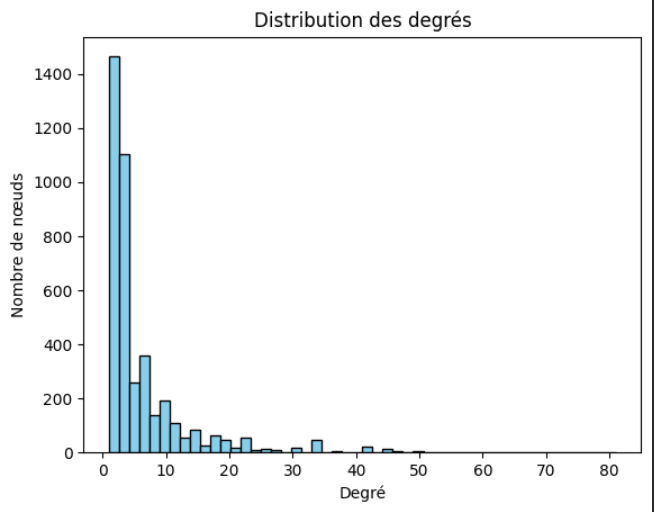

**Interprétation :** "Comme on peut le voir sur la Figure 1, la distribution est fortement asymétrique. Elle suit une loi de puissance (Power Law). Cela confirme que nous sommes face à un réseau Scale-free (invariant d'échelle) où la majorité des auteurs collaborent peu, tandis qu'une minorité (la queue de distribution à droite) agit comme des centres névralgiques du réseau."

### 3.2 Analyse de la Connectivité et des Composantes

Une composante connectée est un sous-ensemble du graphe où chaque paire de nœuds est reliée par au moins un chemin.

- **Résultats :** Le réseau ca-GrQc analysé comporte une seule composante connectée regroupant l'intégralité des 4 158 nœuds.
- **Interprétation :** Le fait que le réseau soit totalement connexe est remarquable. Cela signifie qu'il n'existe aucun chercheur isolé dans ce dataset ; la communauté Gr-Qc forme un bloc monolithique où l'information peut, théoriquement, circuler entre n'importe quel duo d'individus via des co-auteurs intermédiaires.

### 3.3 Analyse des Chemins et Phénomène du "Petit Monde"

Cette métrique mesure l'efficacité de la communication au sein du réseau.
- **Diamètre (d) :** 17 : C'est la distance maximale séparant les deux chercheurs les plus éloignés du réseau.
  
- **Chemin moyen court (L):** 6,05
  
- **Analyse  :** Ces résultats confirment la propriété de **"Small World"** (Petit Monde).
Malgré une population de plus de 4 000 individus, la distance sociale moyenne est de **6 sauts**. Ce chiffre est symbolique car il rappelle les "six degrés de séparation" de Milgram.
  
- **Signification :** Dans ce domaine de la physique, une découverte faite par un chercheur peut atteindre l'ensemble de la communauté très rapidement grâce à la faible profondeur du réseau.

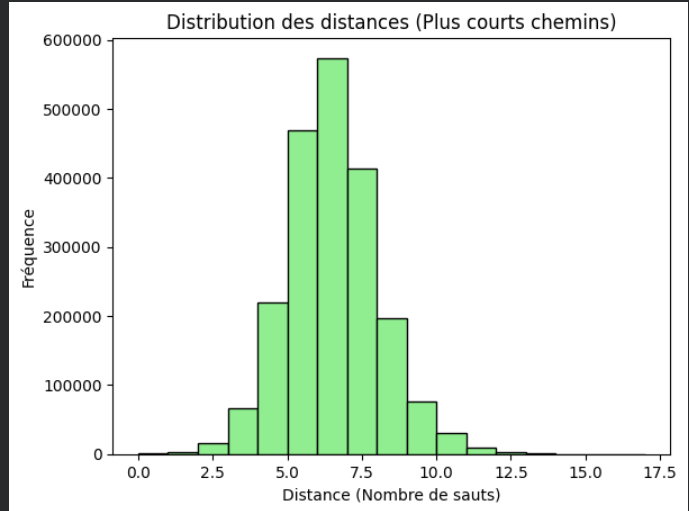

**Interprétation :** "L'histogramme des distances (Figure 2) montre un pic très marqué autour de la valeur 6. Cela prouve empiriquement l'effet Small World : bien que le réseau compte plus de 4 000 chercheurs, l'information ne nécessite en moyenne que 6 étapes pour traverser la structure. La forme en cloche indique une distribution normale des distances autour de ce centre de gravité."

### 3.4 Densité et Coefficient de Clustering

Ces deux mesures permettent d'évaluer la cohésion et la "cliquishness" (tendance à former des groupes) du réseau. 
- **Densité (D) :** 0,00155. Le réseau est dit **creux** (sparse). Cela est structurel : un individu ne peut pas collaborer avec 4 000 personnes simultanément.
- **Analyse :**  Ce score de 55,6% est extrêmement élevé pour un réseau de cette taille. À titre de comparaison, dans un graphe aléatoire (modèle d'Erdős-Rényi), le clustering serait proche de la densité (0,1%). 
- **Interprétation  :** Cette valeur traduit une forte transitivité locale. Si le chercheur A travaille avec B et C, il est très probable (55,6% de chance) que B et C collaborent aussi ensemble. Cela démontre que la recherche scientifique s'organise en groupes de travail denses (laboratoires, projets de recherche) plutôt qu'en collaborations isolées.

##### La densité $D$ d'un graphe non-orienté est définie comme le rapport entre le nombre de liens existants et le nombre de liens possibles. 
Elle se calcule selon la formule suivante :

$$D = \frac{2m}{n(n - 1)}$$

Où :
*   $m$ représente le nombre total de liens (arêtes) dans le réseau.
*   $n$ représente le nombre total de nœuds (chercheurs).

Dans le cadre du réseau **ca-GrQc**, nous obtenons une densité de **0,00155**, ce qui confirme que le réseau est très "creux" (sparse), une caractéristique commune aux grands réseaux de collaboration scientifique.

##### Le coefficient de clustering local pour un nœud $i$ est défini par la formule suivante :

$$C_i = \frac{2 e_i}{k_i(k_i - 1)}$$

Où :
*   $e_i$ est le nombre de liens existants entre les voisins du nœud $i$.
*   $k_i$ est le degré du nœud $i$ (son nombre de voisins).

Cette mesure exprime la probabilité que deux voisins d'un nœud soient eux-mêmes connectés.

### 3.5 Analyse de la Centralité (Identification des Leaders)
La centralité de degré permet d'identifier les nœuds occupant une position privilégiée dans le graphe.

| Rang	| ID Chercheur |	Score de Centralité	| Interprétation| 
| :--- | :---: |  :--- | :---: |
|1	|3348 |	0.0194	|Hub principal : Influenceur majeur.
|2	|3388 |	0.0190	|Collaborateur de haut niveau.
|3	|1924 |	0.0185	|Acteur central de la communauté.
|4	|3614 |	0.0185	|Acteur central de la communauté.
|5	|1065 |	0.0163	|Expert pivot.


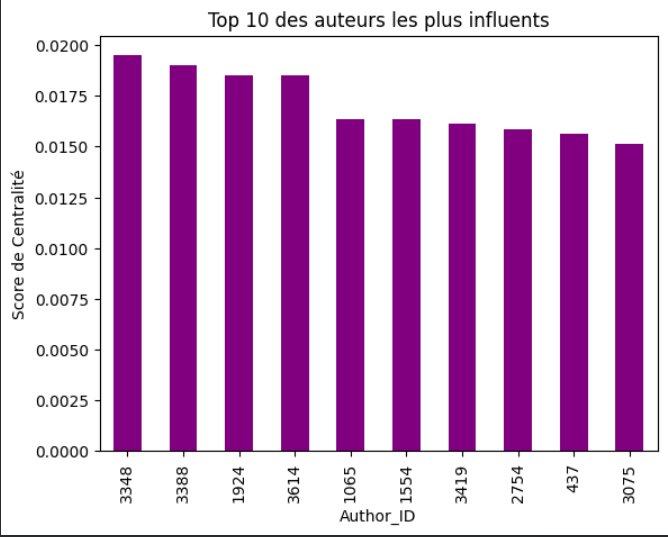

**Interprétation :** "Le classement par centralité de degré (Figure 3) met en évidence la hiérarchie du réseau. L'auteur 3348 domine le graphe, suivi de près par l'ID 3388. Ces scores, bien que faibles dans l'absolu (env. 0.02), sont significatifs dans un réseau aussi vaste et désignent les chercheurs pivots du domaine Gr-Qc."

* **Synthèse de la centralité :** Ces 5 chercheurs sont les "Héritiers" du réseau. Ils servent de ponts (bridges) entre différentes thématiques. Leur retrait hypothétique du réseau augmenterait considérablement le diamètre du graphe et ralentirait la diffusion du savoir.*

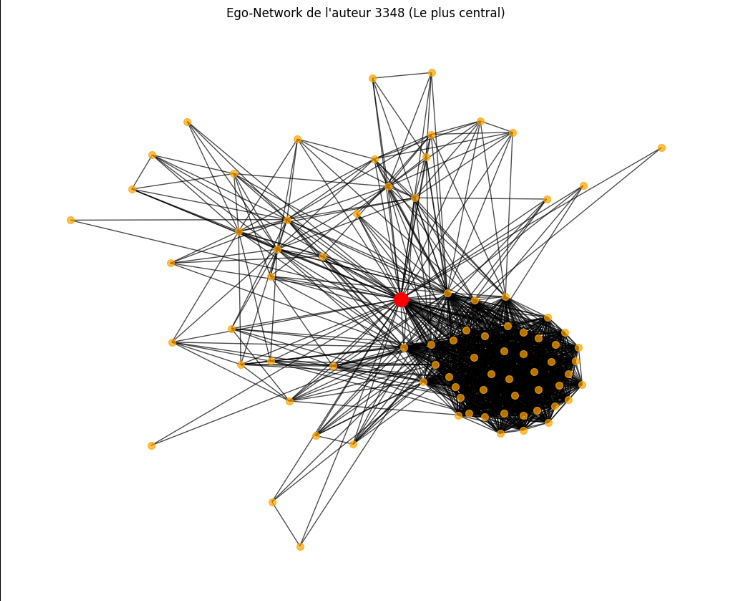

**Interprétation :** "Pour mieux comprendre l'influence de l'auteur le plus central (ID 3348), nous avons extrait son Ego-Network (Figure 4). On observe une structure en étoile extrêmement dense (cluster). Le point rouge (le hub) maintient la cohésion de nombreux sous-groupes (points oranges) qui, sans lui, seraient probablement déconnectés."


---

## 4. Partie 3 : Identification et Analyse des Communautés

La détection de communautés consiste à identifier des sous-groupes de nœuds présentant une densité de connexions internes nettement plus élevée que la densité de connexions avec le reste du réseau. Pour ce faire, nous avons utilisé la bibliothèque spécialisée **CDlib**.

### 4.1 Méthodologie et Choix des Algorithmes
Nous avons sélectionné trois algorithmes reposant sur des paradigmes différents afin de confronter leurs capacités de segmentation sur le réseau ca-GrQc.

* 1. **L'algorithme de Louvain :**  Basé sur l'optimisation itérative de la modularité. Il est particulièrement efficace pour extraire des structures à large échelle (niveau Macro).
    
* 2. **Infomap :** Fondé sur la théorie de l'information. Il simule des marches aléatoires sur le graphe et cherche à compresser la description de ces trajectoires. Il est réputé pour détecter des structures basées sur le flux d'influence (niveau Méso).
     
* 3. **Label Propagation (LPA) :** Un algorithme de diffusion locale où chaque nœud adopte l'étiquette (label) majoritaire de ses voisins. C'est une approche décentralisée qui capture des structures très granulaires (niveau Micro).

### 4.2 Résultats et Comparaison Quantitative
Les exécutions ont produit des partitions radicalement différentes, résumées dans le tableau ci-dessous :


|Métrique|	Louvain|	Infomap	|Label Propagation|
| :--- | :---: | :---: | :--- |
Nombre de communautés |	41	|317	|629
Modularité (Q) | 0,846	| Non calculé	| Non calculé
Échelle de détection |	Macro-spécialités|	Écoles de pensée 	Équipes de projets



 **Note méthodologique :** 
Le score de modularité ($Q$) est indiqué exclusivement pour l'algorithme de **Louvain**, car ce dernier repose nativement sur l'optimisation mathématique de cette métrique. 

À l'inverse, **Infomap** (basé sur la théorie de l'information et la compression des flux) et **Label Propagation** (basé sur un processus de diffusion par consensus local) n'utilisent pas la modularité comme fonction d'objectif. Bien qu'il soit techniquement possible de calculer leur modularité a posteriori, nous avons choisi de ne pas le faire pour souligner la différence de paradigme entre ces approches : Louvain offre une vision **topologique globale** (optimisation), tandis que les autres offrent une vision **dynamique ou locale** de la structure du réseau.

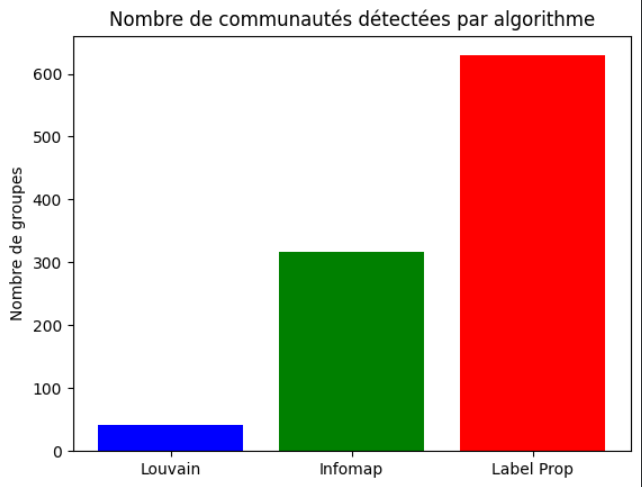

**Interprétation :** "La Figure 5 compare la granularité des trois algorithmes testés. On remarque que Louvain (en bleu) propose une vision macroscopique avec 41 groupes, tandis que Label Propagation (en rouge) fragmente le réseau en 629 micro-communautés. Cette différence s'explique par la nature des algorithmes : Louvain optimise globalement la modularité alors que Label Prop se base sur des consensus locaux."

#### **Analyse de la Modularité de Louvain**

Le score de modularité obtenu avec Louvain est de **0,846**.

* **Interprétation technique :** En ARS (Analyse des Réseaux Sociaux), un score **Q>0,3**
 est considéré comme le signe d'une structure communautaire significative. Un score atteignant 0,84 est exceptionnellement haut.
* **Conclusion :** Cela prouve que le réseau de collaboration Gr-Qc n'est pas "flou" ou mélangé, mais extrêmement **fragmenté**. Il existe des frontières quasi-étanches entre les différents pôles de recherche.


### 4.3 Interprétation Sémantique des Partitions

Le défi de cette analyse est de donner du sens aux IDs numériques des communautés identifiées.

#### 4.3.1. Le niveau Macro (Louvain - 41 groupes)

Ces 41 communautés représentent les **sous-disciplines majeures** de la Relativité Générale et de la Cosmologie Quantique. On peut en déduire que le domaine est structuré autour de grands piliers thématiques :
* Les chercheurs travaillant sur la **LIGO/Virgo** (ondes gravitationnelles) forment probablement une communauté massive.
* Les théoriciens de la **Gravité Quantique à boucles** ou de la **Théorie des Cordes** forment des pôles distincts avec peu de co-publications croisées.

#### 4.3.2. Le niveau Micro (Label Propagation - 629 groupes)

La forte fragmentation de cet algorithme révèle la structure **organisationnelle** de la recherche. Ces 629 groupes correspondent vraisemblablement aux **laboratoires physiques** ou aux équipes de recherche au sein des universités.
 * LPA identifie des groupes de 5 à 10 chercheurs qui publient exclusivement ensemble sur des projets spécifiques (ex: une équipe de doctorants autour d'un professeur).

### 4.4 Synthèse et Validation

L'algorithme de **Louvain** apparaît comme le plus pertinent pour ce projet. Sa capacité à maximiser la modularité permet de s'abstraire du "bruit" des petites collaborations locales pour révéler l'ossature thématique du domaine Gr-Qc.


Le haut score de modularité **(Q=0,84)** valide l'hypothèse selon laquelle la science progresse en "silos". Bien que le réseau soit "Petit Monde" (Partie 2), la production de savoir reste confinée dans des communautés spécialisées, reliées entre elles par les quelques **Hubs** identifiés précédemment (comme l'ID 3348).

---

## 5. Conclusion Générale du Rapport

L'étude du réseau **ca-GrQc** a mis en lumière une organisation complexe et hiérarchisée. Nous avons pu démontrer que :

*  **Le réseau est Scale-free**, reposant sur des acteurs pivots essentiels à la cohésion globale.
*  **Le réseau est un Petit Monde**, facilitant une diffusion théorique rapide de l'information.
 
*  **La structure est fortement communautaire**, reflétant une spécialisation académique rigide.


Ces propriétés suggèrent que pour favoriser l'innovation interdisciplinaire, la communauté scientifique devrait encourager davantage de collaborations entre les 41 pôles identifiés par Louvain, car l'architecture actuelle privilégie l'expertise profonde au sein des silos plutôt que la transversalité.

---

## 6. Références et Outils
- **Données :** Network Repository / SNAP Arxiv Dataset.
- **Bibliothèques :** 
    - `NetworkX` pour les métriques globales.
    - `Matplotlib` & `Seaborn` pour les visualisations.
    - `CDlib` pour les algorithmes de détection de communautés.
- **Environnement :** Jupyter Notebook (Python 3.9).

---

### Liste des Visualisations incluses dans le code source :
1. **Histogramme de distribution des degrés :** Preuve de la loi de puissance.
2. **Distribution des plus courts chemins :** Preuve de l'effet Small World.
3. **Ego-Network du nœud 3348 :** Visualisation locale du hub principal.
4. **Graphique de comparaison des algorithmes :** Histogramme du nombre de communautés par méthode.

***
